# Cancer Mutation Classification — Oncogenicity-Focused Analysis
This pipeline classifies genetic mutations as **Oncogenic** or **Non-Oncogenic** using a multi-tiered labeling strategy based on ClinVar's Oncogenicity annotations, Somatic Clinical Impact tiers, and cancer-phenotype-matched pathogenicity data.

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_clean_data
from src.features import FeatureEngineer
from src.training import train_pipeline
from src.evaluation import evaluate_medical_utility, plot_visual_assessment
from src.config import RANDOM_STATE, TEST_SIZE

from src.gpu_setup import setup_gpu
setup_gpu()

I0000 00:00:1776972624.248916   22098 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776972624.294700   22098 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776972625.472690   22098 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ GPU Mode Active: 1 Physical GPUs, 1 Logical GPUs configured.


I0000 00:00:1776972627.004375   22098 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2285 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 1. Data Procurement
Loading variants with multi-tiered cancer-specific labeling:
- **Tier 1 (Gold):** ClinVar Oncogenicity = "Oncogenic" or "Likely oncogenic"
- **Tier 2 (Silver):** Somatic Clinical Impact = Tier I or Tier II
- **Tier 3 (Bronze):** Pathogenic + Cancer phenotype keywords
- **Negative:** ClinSigSimple = 0 (reliably benign)

In [2]:
df = load_clean_data()

train_df, test_df = train_test_split(
    df, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=df['CancerLabel']
)

print(f"Training set: {len(train_df)} variants")
print(f"Test set: {len(test_df)} variants")

Dataset successfully loaded. Final size: 600184 variants.
  Oncogenic (positive): 23297 (3.9%)
  Benign (negative):    576887 (96.1%)
Training set: 510156 variants
Test set: 90028 variants


## 2. Feature Engineering & Preparation
Extracting biological features: Ti/Tv ratio, origin (somatic/germline), allele length, gene-level oncogenic frequency, and categorical embeddings for Gene, Chromosome, Variant Type, and Origin.

In [3]:
engineer = FeatureEngineer()
X_train = engineer.fit_transform(train_df)
X_test = engineer.transform(test_df)

y_train = train_df['CancerLabel'].values
y_test = test_df['CancerLabel'].values

## 3. Neural Architecture & Training
The model uses Focal Loss (alpha=0.75) combined with computed class weights to handle severe class imbalance. Architecture: 256→128→64 dense layers with embedding inputs for categorical features.

In [4]:
model, history = train_pipeline(X_train, y_train, engineer)

Class weights: {np.int64(0): np.float64(0.5201915350950538), np.int64(1): np.float64(12.88142611857388)}
Epoch 1/100


I0000 00:00:1776972676.702130   22190 service.cc:153] XLA service 0x7f703c038a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776972676.702152   22190 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1776972676.747156   22190 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776972677.020634   22190 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1776972677.077297   22190 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3966__.38
I0000 00:00:1776972679.666586   22284 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_maximum_reduce_fusion', 4 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776972679.716509   22284 subprocess_compilation.cc:3

 76/847 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8570 - loss: 0.0386 - precision: 0.1961 - recall: 0.5997

I0000 00:00:1776972681.856225   22190 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_maximum_reduce_fusion_1', 4 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_maximum_reduce_fusion', 4 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776972681.875613   22190 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


842/847 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9428 - loss: 0.0166 - precision: 0.4032 - recall: 0.6352

I0000 00:00:1776972683.864115   22190 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3966__.38


847/847 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9429 - loss: 0.0166 - precision: 0.4038 - recall: 0.6354

I0000 00:00:1776972689.127068   22185 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


847/847 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9611 - loss: 0.0118 - precision: 0.4986 - recall: 0.6604 - val_accuracy: 0.9760 - val_loss: 0.0095 - val_precision: 0.7548 - val_recall: 0.5688 - learning_rate: 0.0010
Epoch 2/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9721 - loss: 0.0090 - precision: 0.6257 - recall: 0.6949 - val_accuracy: 0.9766 - val_loss: 0.0089 - val_precision: 0.7337 - val_recall: 0.6291 - learning_rate: 0.0010
Epoch 3/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9733 - loss: 0.0084 - precision: 0.6415 - recall: 0.7051 - val_accuracy: 0.9755 - val_loss: 0.0088 - val_precision: 0.6881 - val_recall: 0.6796 - learning_rate: 0.0010
Epoch 4/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9734 - loss: 0.0082 - precision: 0.6410 - recall: 0.7124 - val_accuracy: 0.9723 - val_loss: 0.0091 - val_precision: 0.6277 - val_recall: 0.7168 - learning_rate: 0.0010
Epoch 5/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.974

## 4. Medical Utility Assessment

2814/2814 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

--- Clinical Performance Appraisal (Threshold: 0.3519) ---
                   precision    recall  f1-score   support

Non-Oncogenic (0)       1.00      0.92      0.96     86533
    Oncogenic (1)       0.31      0.90      0.46      3495

         accuracy                           0.92     90028
        macro avg       0.65      0.91      0.71     90028
     weighted avg       0.97      0.92      0.94     90028



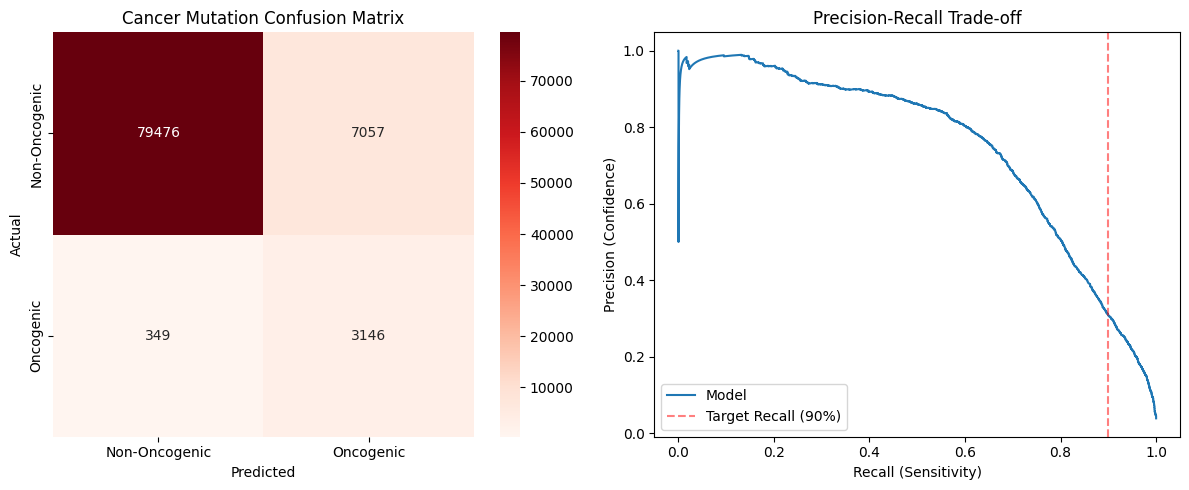

In [5]:
y_pred, y_probs, threshold = evaluate_medical_utility(model, X_test, y_test)
plot_visual_assessment(y_test, y_pred, y_probs)

## 5. Interactive Clinical Inference & Interpretation
This section allows biologists to test the model with individual mutations and receive a human-readable clinical report instead of raw metrics.

In [7]:
from src.evaluation import report_inference

# --- INTERACTIVE TEST AREA ---
# You can change these values to test any mutation.
# The example below is the BRAF V600E mutation (Common in Melanoma).

test_variant = {
    'GeneID': 673,                # Gene ID (BRAF)
    'GeneSymbol': 'BRAF',         # Gene Symbol
    'PositionVCF': 140753336,     # Genomic Position (VCF format)
    'ReferenceAlleleVCF': 'A',    # Reference Base
    'AlternateAlleleVCF': 'T',    # Mutant Base
    'Type': 'snp',                # Variant Type (snp, del, ins, etc.)
    'Chromosome': '7',
    'OriginSimple': 'somatic'     # Somatic origin — typical for cancer mutations
}

test_kras_g12d = {
    'GeneID': 3845,
    'GeneSymbol': 'KRAS',
    'PositionVCF': 25245350,      # GRCh38
    'ReferenceAlleleVCF': 'C',
    'AlternateAlleleVCF': 'T',    # c.35G>A on reverse strand
    'Type': 'snp',
    'Chromosome': '12',
    'OriginSimple': 'somatic'
}

test_tp53_r175h = {
    'GeneID': 7157,
    'GeneSymbol': 'TP53',
    'PositionVCF': 7674220,       # GRCh38, reverse strand
    'ReferenceAlleleVCF': 'C',
    'AlternateAlleleVCF': 'T',
    'Type': 'snp',
    'Chromosome': '17',
    'OriginSimple': 'somatic'
}

test_pik3ca = {
    'GeneID': 5290,
    'GeneSymbol': 'PIK3CA',
    'PositionVCF': 179234297,     # GRCh38
    'ReferenceAlleleVCF': 'A',
    'AlternateAlleleVCF': 'G',
    'Type': 'snp',
    'Chromosome': '3',
    'OriginSimple': 'somatic'
}

test_tp53_benign = {
    'GeneID': 7157,
    'GeneSymbol': 'TP53',
    'PositionVCF': 7676154,       # GRCh38
    'ReferenceAlleleVCF': 'G',
    'AlternateAlleleVCF': 'C',
    'Type': 'snp',
    'Chromosome': '17',
    'OriginSimple': 'germline'    # Key difference — germline
}

test_egfr = {
    'GeneID': 1956,
    'GeneSymbol': 'EGFR',
    'PositionVCF': 55259515,      # GRCh38
    'ReferenceAlleleVCF': 'T',
    'AlternateAlleleVCF': 'G',
    'Type': 'snp',
    'Chromosome': '7',
    'OriginSimple': 'germline'    # Intentionally set to germline (not somatic)
}


# report_inference(model, engineer, test_variant, threshold)
report_inference(model, engineer, test_kras_g12d, threshold)
report_inference(model, engineer, test_tp53_r175h, threshold)
report_inference(model, engineer, test_pik3ca, threshold)
report_inference(model, engineer, test_tp53_benign, threshold)
report_inference(model, engineer, test_egfr, threshold)




      CANCER MUTATION CLINICAL REPORT
VARIANT: KRAS (ID: 3845) | Pos: 25245350
DNA CHANGE: C -> T
ORIGIN: somatic
--------------------------------------------------
FINAL CLASSIFICATION: PATHOGENIC (ONCOGENIC)
CONFIDENCE SCORE: 76.0%
RISK LEVEL: MODERATE
--------------------------------------------------
BIOLOGICAL CONTEXT:
 - Gene Profile: KRAS (ID: 3845) has a 20.2% oncogenic mutation rate in training data.
 - Mutation Type: snp (Transition)

CLINICAL ADVICE:
 [!] High priority for clinical follow-up.
 [!] Mutation shows genomic signatures common in cancer drivers.

      CANCER MUTATION CLINICAL REPORT
VARIANT: TP53 (ID: 7157) | Pos: 7674220
DNA CHANGE: C -> T
ORIGIN: somatic
--------------------------------------------------
FINAL CLASSIFICATION: PATHOGENIC (ONCOGENIC)
CONFIDENCE SCORE: 77.8%
RISK LEVEL: MODERATE
--------------------------------------------------
BIOLOGICAL CONTEXT:
 - Gene Profile: TP53 (ID: 7157) has a 36.1% oncogenic mutation rate in training data.
 - Mutation 